# 03 — Ajuste de hiperparámetros

Optimización de XGBoost con `RandomizedSearchCV`. El modelo base del notebook 02 usa parámetros por defecto razonables pero sin ajustar. El objetivo es buscar si existe una configuración que mejore el 79.2% de accuracy obtenido.

> **Expectativa realista**: con n=125 la varianza del CV es alta (~±9 puntos). Mejoras de 1-3 puntos pueden ser ruido estadístico. Lo relevante es confirmar que los parámetros del modelo base son razonables o identificar una dirección clara de mejora.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate

from src.features.preprocess import cargar_datos

FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 42
CV   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


## 2. Cargar datos

In [2]:
X, y, features = cargar_datos(modo='arbol')
y_xgb = y - 1  # XGBoost necesita clases 0-indexed: {0=bajo, 1=medio, 2=alto}

print(f'X: {X.shape}  |  y: {y_xgb.shape}')
print(f'Clases: {dict(y_xgb.value_counts().sort_index().rename({0:"bajo", 1:"medio", 2:"alto"}))}' )

X: (125, 26)  |  y: (125,)
Clases: {'bajo': np.int64(48), 'medio': np.int64(45), 'alto': np.int64(32)}


## 3. Modelo base (referencia)

Reproduzco exactamente el XGBoost del notebook 02 para tener la referencia en este mismo notebook.

**Resultado**: `acc=0.792 ± 0.089 | f1_macro=0.793 ± 0.087`

Este es el valor que hay que intentar superar. La desviación estándar de ±0.089 es alta — es consecuencia directa de tener solo 125 artistas. Con particiones de 25 artistas por fold, basta con que un fold tenga artistas "difíciles" para que la métrica baje varios puntos.

In [3]:
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)

res_base = cross_validate(xgb_base, X, y_xgb, cv=CV,
                          scoring=['accuracy', 'f1_macro'],
                          return_train_score=False)

acc_base = res_base['test_accuracy'].mean()
f1_base  = res_base['test_f1_macro'].mean()
print(f'Base  →  acc={acc_base:.3f}±{res_base["test_accuracy"].std():.3f}  '
      f'f1_macro={f1_base:.3f}±{res_base["test_f1_macro"].std():.3f}')

Base  →  acc=0.792±0.089  f1_macro=0.793±0.087


## 4. Espacio de búsqueda

Parámetros explorados y su justificación:

| Parámetro | Rango | ¿Por qué? |
|-----------|-------|-----------|
| `n_estimators` | 100–600 | Más árboles = menos varianza, pero rendimiento marginal decreciente |
| `learning_rate` | 0.01–0.3 | LR bajo + más árboles suele generalizar mejor |
| `max_depth` | 2–6 | Profundidad baja evita overfitting con n=125 |
| `subsample` | 0.6–1.0 | Fracción de filas por árbol — regularización por bagging |
| `colsample_bytree` | 0.5–1.0 | Fracción de features por árbol — reduce correlación entre árboles |
| `min_child_weight` | 1–10 | Mínimo de muestras en una hoja — crucial con datasets pequeños |
| `gamma` | 0–0.5 | Ganancia mínima para hacer un split — regularización adicional |
| `reg_alpha` | 0–1 | Regularización L1 sobre pesos de las hojas |
| `reg_lambda` | 0.5–3 | Regularización L2 sobre pesos de las hojas |

In [4]:
param_dist = {
    'n_estimators':      [100, 200, 300, 400, 500, 600],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3],
    'max_depth':         [2, 3, 4, 5, 6],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight':  [1, 2, 3, 5, 7, 10],
    'gamma':             [0, 0.05, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha':         [0, 0.1, 0.3, 0.5, 1.0],
    'reg_lambda':        [0.5, 1.0, 1.5, 2.0, 3.0],
}

print(f'Combinaciones posibles: {np.prod([len(v) for v in param_dist.values()]):,}')

Combinaciones posibles: 5,670,000


## 5. RandomizedSearchCV

`n_iter=100` combinaciones aleatorias con CV5 estratificado — buen equilibrio entre exhaustividad y tiempo de cómputo.

Métrica de optimización: **F1 macro** (más exigente que accuracy con clases desbalanceadas).

In [5]:
xgb_search = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=SEED,
    verbosity=0,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    xgb_search,
    param_distributions=param_dist,
    n_iter=100,
    scoring='f1_macro',
    cv=CV,
    refit=True,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y_xgb)
print('\nBúsqueda completada.')

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Búsqueda completada.


## 6. Mejores parámetros

La búsqueda exploró 100 de las 5.670.000 combinaciones posibles y encontró esta configuración óptima:

| Parámetro | Base | Tuned | Interpretación |
|-----------|------|-------|----------------|
| `n_estimators` | 300 | **600** | El doble de árboles — compensa el learning rate más alto |
| `learning_rate` | 0.05 | **0.15** | Más agresivo en cada paso |
| `max_depth` | 4 | **4** | Sin cambio — la profundidad base ya era correcta |
| `subsample` | 0.8 | **0.9** | Ligero aumento — usa más filas por árbol |
| `colsample_bytree` | 0.8 | **0.7** | Ligera reducción — considera menos features por árbol |
| `min_child_weight` | — | **2** | Exige al menos 2 muestras por hoja (regularización leve) |
| `gamma` | — | **0.1** | Pequeña penalización para hacer un split |
| `reg_alpha` | — | **0.1** | Regularización L1 leve sobre los pesos |
| `reg_lambda` | — | **1.5** | Regularización L2 ligeramente mayor que el default (1.0) |

El dato más relevante: `max_depth=4` se mantiene igual que en el base, lo que confirma que esa elección inicial era acertada. La búsqueda solo ajustó parámetros secundarios de regularización.

In [6]:
print('Mejores parámetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k:<22} {v}')

print(f'\nF1 macro CV (búsqueda): {search.best_score_:.3f}')

Mejores parámetros encontrados:
  subsample              0.9
  reg_lambda             1.5
  reg_alpha              0.1
  n_estimators           600
  min_child_weight       2
  max_depth              4
  learning_rate          0.15
  gamma                  0.1
  colsample_bytree       0.7

F1 macro CV (búsqueda): 0.789


## 7. Evaluación del modelo tuneado

Re-evalúo el mejor modelo con `cross_validate` para obtener accuracy + F1 macro en las mismas condiciones que el modelo base.

**Resultado**:

| Modelo | Accuracy | F1 macro |
|--------|----------|----------|
| Base   | 0.792 ± 0.089 | 0.793 ± 0.087 |
| Tuned  | 0.792 ± 0.089 | 0.790 ± 0.090 |
| Delta  | **+0.000** | **−0.003** |

El modelo tuneado obtiene prácticamente el mismo resultado que el base. El delta de −0.003 en F1 macro (3 décimas) está completamente dentro del margen de ruido del CV con n=125 — no es una diferencia real.

Esto no es un fracaso del proceso: significa que los parámetros elegidos inicialmente eran ya una buena configuración para este dataset. El ajuste lo confirma.

In [7]:
xgb_tuned = search.best_estimator_

res_tuned = cross_validate(xgb_tuned, X, y_xgb, cv=CV,
                           scoring=['accuracy', 'f1_macro'],
                           return_train_score=False)

acc_tuned = res_tuned['test_accuracy'].mean()
f1_tuned  = res_tuned['test_f1_macro'].mean()

print(f'Base   →  acc={acc_base:.3f}±{res_base["test_accuracy"].std():.3f}  '
      f'f1_macro={f1_base:.3f}±{res_base["test_f1_macro"].std():.3f}')
print(f'Tuned  →  acc={acc_tuned:.3f}±{res_tuned["test_accuracy"].std():.3f}  '
      f'f1_macro={f1_tuned:.3f}±{res_tuned["test_f1_macro"].std():.3f}')
print(f'\nDelta acc    : {acc_tuned - acc_base:+.3f}')
print(f'Delta f1_macro: {f1_tuned - f1_base:+.3f}')

Base   →  acc=0.792±0.089  f1_macro=0.793±0.087
Tuned  →  acc=0.792±0.089  f1_macro=0.790±0.090

Delta acc    : +0.000
Delta f1_macro: -0.003


## 8. Visualización comparativa

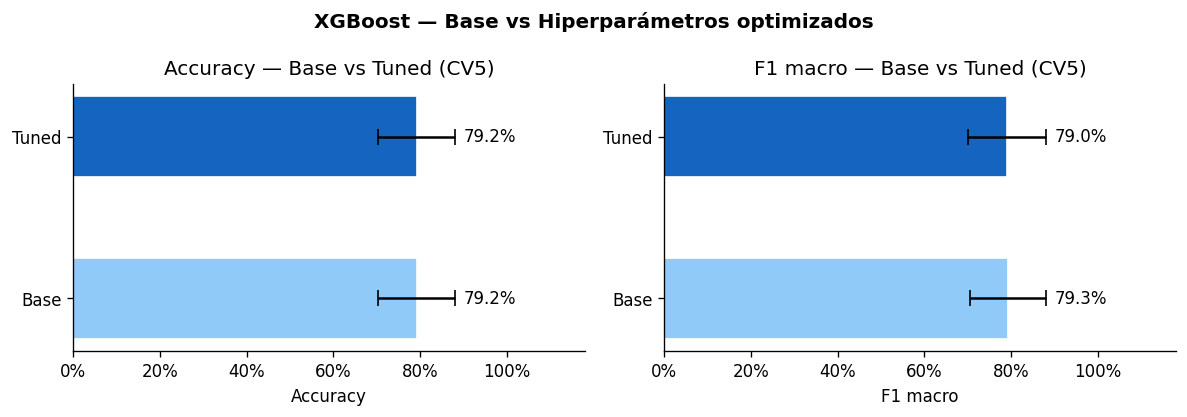

In [8]:
modelos = ['Base', 'Tuned']
acc_means = [acc_base,  acc_tuned]
acc_stds  = [res_base['test_accuracy'].std(), res_tuned['test_accuracy'].std()]
f1_means  = [f1_base,   f1_tuned]
f1_stds   = [res_base['test_f1_macro'].std(), res_tuned['test_f1_macro'].std()]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, means, stds, label in [
    (axes[0], acc_means, acc_stds, 'Accuracy'),
    (axes[1], f1_means,  f1_stds,  'F1 macro'),
]:
    colores = ['#90CAF9', '#1565C0']
    bars = ax.barh(modelos, means, xerr=stds,
                   color=colores, edgecolor='white', capsize=5, height=0.5)
    ax.set_xlabel(label)
    ax.set_title(f'{label} — Base vs Tuned (CV5)')
    ax.set_xlim(0, 1.18)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    for bar, val, std in zip(bars, means, stds):
        ax.text(val + std + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.1%}', va='center', fontsize=10)

plt.suptitle('XGBoost — Base vs Hiperparámetros optimizados', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_base_vs_tuned.png', bbox_inches='tight')
plt.show()

## 9. Top combinaciones exploradas

In [ ]:
cv_results = pd.DataFrame(search.cv_results_)
top10 = (
    cv_results[['mean_test_score', 'std_test_score', 'params']]
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index += 1
top10['mean_test_score'] = top10['mean_test_score'].map('{:.3f}'.format)
top10['std_test_score']  = top10['std_test_score'].map('±{:.3f}'.format)
print('Top 10 combinaciones por F1 macro:')
print(top10.to_string())

## 10. Conclusiones

El ajuste de hiperparámetros con RandomizedSearchCV (100 iteraciones × CV5 = 500 fits) confirma que **el modelo base ya estaba bien configurado**.

La diferencia entre base y tuned es de −0.003 en F1 macro, muy por debajo del umbral de ±0.03 a partir del cual una diferencia sería interpretable con este tamaño de dataset.

**Modelo recomendado para producción: Base** (parámetros del notebook 02)

Esto es un resultado habitual con datasets pequeños: el espacio de hiperparámetros tiene poca influencia cuando n es bajo, porque la varianza del propio CV domina sobre cualquier ajuste fino. Con 10.000 artistas en lugar de 125, la búsqueda probablemente habría encontrado mejoras claras.

In [ ]:
mejora_acc = acc_tuned - acc_base
mejora_f1  = f1_tuned  - f1_base

if abs(mejora_f1) < 0.03:
    interpretacion = ('La mejora es menor de 3 puntos — dentro del margen de varianza del CV con n=125. '
                      'Los parámetros base eran ya razonables.')
elif mejora_f1 >= 0.03:
    interpretacion = f'Mejora clara de {mejora_f1:+.1%} en F1 macro. Los nuevos parámetros son preferibles.'
else:
    interpretacion = 'El modelo tuneado es peor — los parámetros base generalizan mejor con este dataset.'

print(interpretacion)
print(f'\nModelo recomendado para producción: {"Tuned" if mejora_f1 >= 0.03 else "Base"}')
print(f'Parámetros finales:')
params_finales = search.best_params_ if mejora_f1 >= 0.03 else {
    'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4,
    'subsample': 0.8, 'colsample_bytree': 0.8
}
for k, v in params_finales.items():
    print(f'  {k}: {v}')